In [26]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import riskfolio as rp
import yfinance as yf

warnings.filterwarnings("ignore")
pd.options.display.float_format = "{:.4%}".format

In [50]:
start = "2023-01-01" 
end = "2025-03-31"
assets = [
"GTLB", "NVDA", "AMZN", "HOOD", "PLTR", "SOFI", "AFRM", "MBLY", "SHOP", 'QQQ', 'APP', 'PATH', 'ARKK', "AMD", "UBER", "COIN", 'U', 'BABA'
]
assets.sort()

data = yf.download(assets, start=start, end=end).Close 
Y = data.pct_change().dropna()

[*********************100%***********************]  18 of 18 completed


In [52]:
port =rp.Portfolio(returns=Y)
method_mu = "hist"
method_cov = "hist"

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

model = "Classic"
rm = "MV" 
obj = "MinRisk"
hist = True
rf = 0
l=0
w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

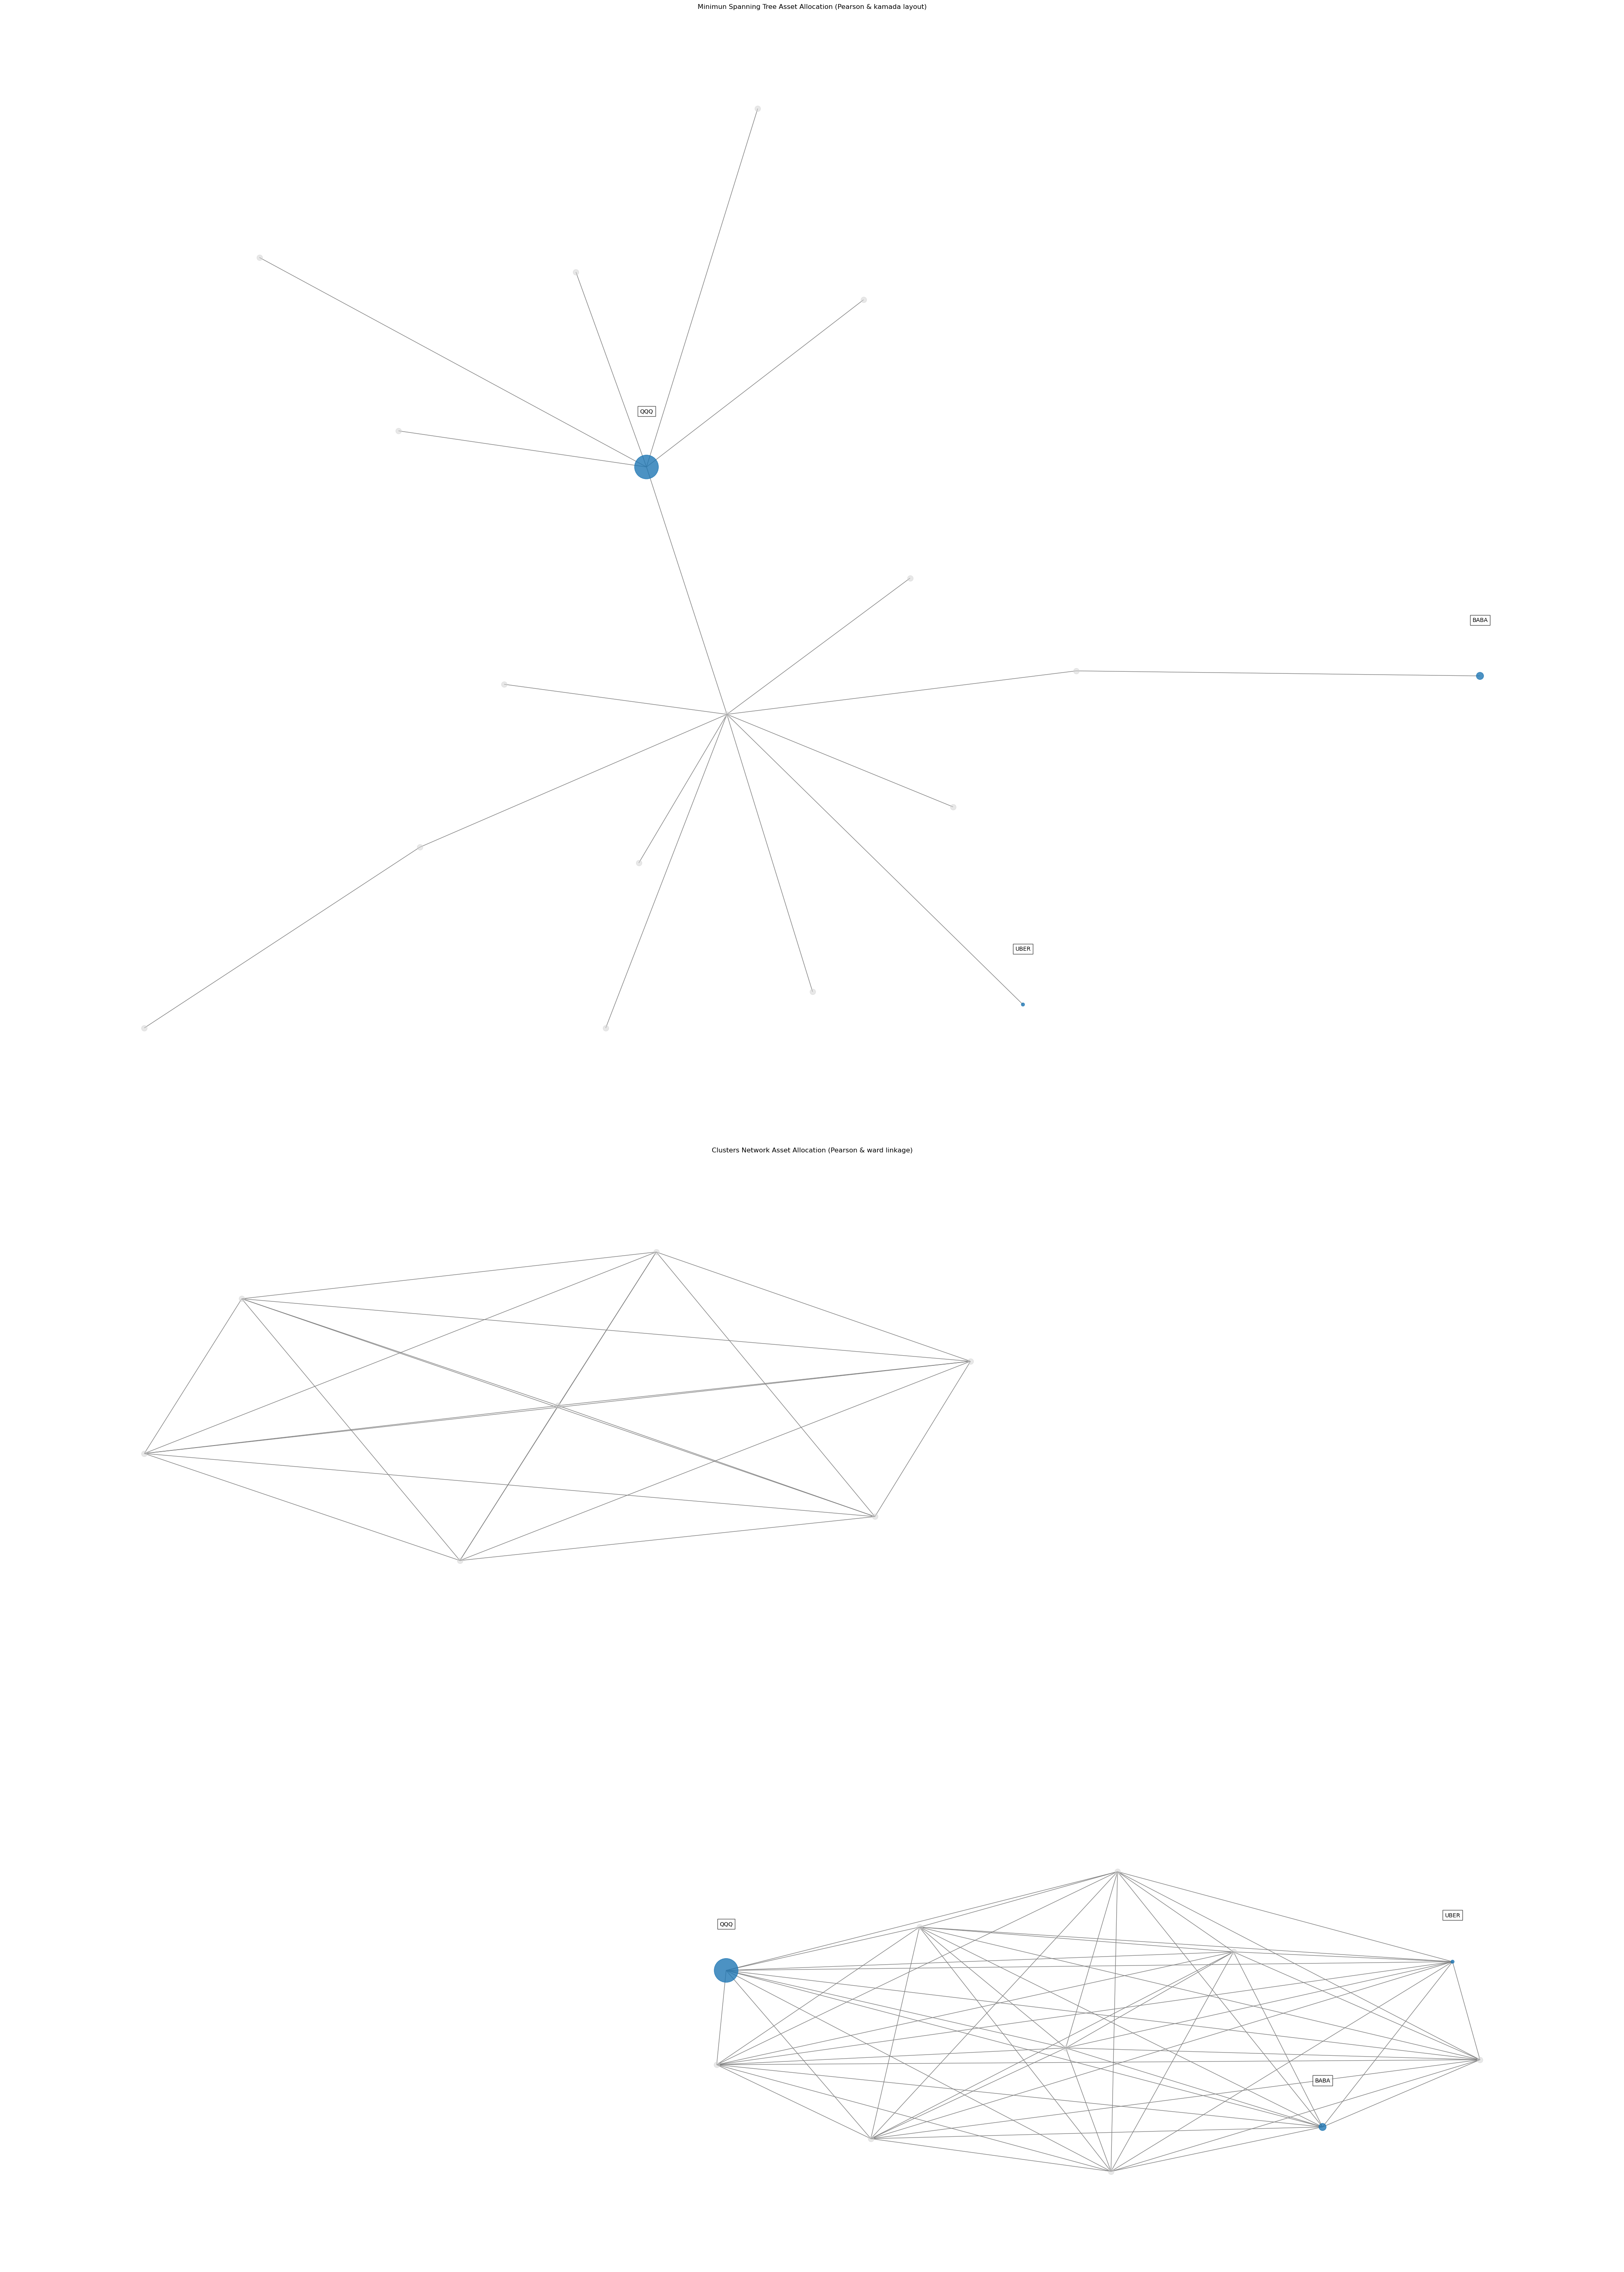

In [56]:
fig, ax = plt.subplots(2, 1, figsize=(40, 56))
ax= np.ravel(ax)

ax[0]= rp.plot_network_allocation(
    returns=Y,
    w=w, 
    codependence="pearson", 
    linkage="ward", 
    alpha_tail=0.05, 
    node_labels=True, 
    leaf_order=True, 
    kind="kamada", 
    seed=123, 
    ax=ax[0],
)
ax[1] =rp.plot_clusters_network_allocation(
returns=Y, w=w, codependence="pearson", linkage="ward", k=None, max_k=10, ax=ax[1] )